<a href="https://colab.research.google.com/github/aayurganesh2007-max/Neural_Networks_with_pytorch/blob/main/claude.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Train : 6,000  |  Val : 2,000  |  Test : 2,000


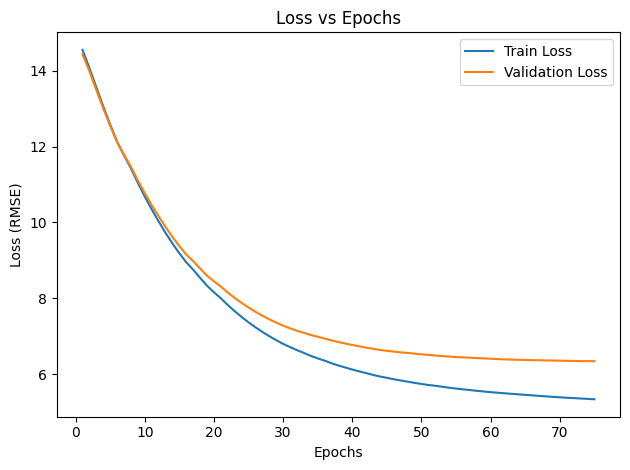

tensor(6.3255)
Mean Absolute Error: 4.765010196685791
Mean Squared Error: 40.011875518272134
R-squared: 0.8178728798806613


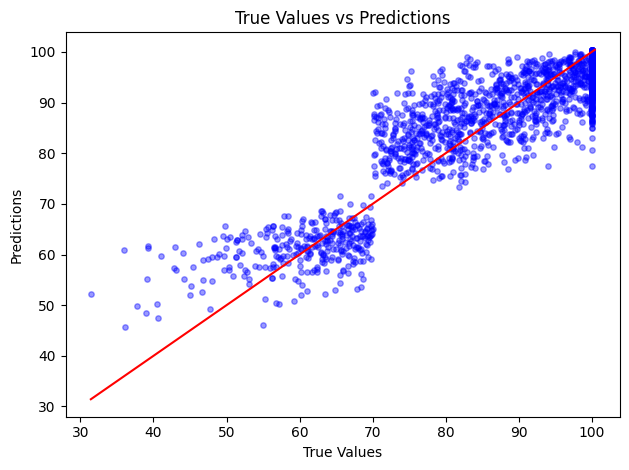

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import LabelEncoder
import xgboost as xgb
import warnings
warnings.filterwarnings("ignore")

# ══════════════════════════════════════════════════════════
# HYPERPARAMETERS  — modify here
# ══════════════════════════════════════════════════════════
EPOCHS        = 75     # number of boosting rounds
LEARNING_RATE = 0.05     # step size per round  (try 0.01 – 0.3)
MAX_DEPTH     = 6        # tree depth           (try 3 – 10)

# Dropout equivalents in XGBoost:
# subsample      → randomly drops ROWS    per tree  (0.0 – 1.0)
# colsample      → randomly drops COLUMNS per tree  (0.0 – 1.0)
# both act as regularisation / dropout, reducing overfitting
SUBSAMPLE     = 0.8      # row dropout rate     (1.0 = no dropout)
COLSAMPLE     = 0.8      # column dropout rate  (1.0 = no dropout)

# ── Load Data ──────────────────────────────────────────────
URL = ("https://raw.githubusercontent.com/aayurganesh2007-max/"
       "Neural_Networks_with_pytorch/refs/heads/main/student_dataset_10000_rows.csv")
df = pd.read_csv(URL)

# ── Clean ──────────────────────────────────────────────────
df.dropna(inplace=True)
le = LabelEncoder()
df["placement_encoded"] = le.fit_transform(df["placement_status"])
df.drop(columns=["placement_status"], inplace=True)

# ── Feature Engineering ────────────────────────────────────
df["study_efficiency"]  = df["study_hours"] * df["attendance"] / 100
df["score_momentum"]    = df["previous_score"] * df["attendance"] / 100
df["distraction_index"] = df["internet_usage"] / (df["assignments_completed"] + 1)
df["sleep_study_ratio"] = df["sleep_hours"] / (df["study_hours"] + 1)
df["assignment_rate"]   = df["assignments_completed"] / (df["study_hours"] + 1)

FEATURES = [
    "study_hours", "attendance", "sleep_hours", "internet_usage",
    "assignments_completed", "previous_score", "placement_encoded",
    "study_efficiency", "score_momentum",
    "distraction_index", "sleep_study_ratio", "assignment_rate",
]
TARGET = "exam_score"

X = df[FEATURES]
y = df[TARGET]

# ── 60 / 20 / 20 Split ────────────────────────────────────
# First cut off 40% (val + test), then split that equally
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.40, random_state=42
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42
)

print(f"Train : {len(X_train):,}  |  Val : {len(X_val):,}  |  Test : {len(X_test):,}")

# ── Train XGBoost ──────────────────────────────────────────
model = xgb.XGBRegressor(
    n_estimators=EPOCHS,
    max_depth=MAX_DEPTH,
    learning_rate=LEARNING_RATE,
    subsample=SUBSAMPLE,
    colsample_bytree=COLSAMPLE,
    eval_metric="rmse",
    random_state=42,
    n_jobs=-1,
    verbosity=0,
)

model.fit(
    X_train, y_train,
    eval_set=[(X_train, y_train), (X_val, y_val)],
    verbose=False,
)

train_loss = model.evals_result()["validation_0"]["rmse"]
val_loss   = model.evals_result()["validation_1"]["rmse"]
epochs = list(range(1, len(train_loss) + 1))

# ── Plot 1: Train & Validation Loss vs Epochs ─────────────
plt.figure()
plt.plot(epochs, train_loss, label="Train Loss")
plt.plot(epochs, val_loss,   label="Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss (RMSE)")
plt.title("Loss vs Epochs")
plt.legend()
plt.tight_layout()
plt.show()

# ── Predict & Print Metrics ────────────────────────────────
y_pred = model.predict(X_test)

test_loss = np.sqrt(mean_squared_error(y_test, y_pred))
mae  = mean_absolute_error(y_test, y_pred)
mse  = mean_squared_error(y_test, y_pred)
r2   = r2_score(y_test, y_pred)

print(f"tensor({test_loss:.4f})")
print(f"Mean Absolute Error: {mae}")
print(f"Mean Squared Error: {mse}")
print(f"R-squared: {r2}")

# ── Plot 2: True vs Predicted Scatter ─────────────────────
plt.figure()
plt.scatter(y_test, y_pred, alpha=0.4, color="blue", s=15)
lo = min(y_test.min(), y_pred.min())
hi = max(y_test.max(), y_pred.max())
plt.plot([lo, hi], [lo, hi], color="red", linewidth=1.5)
plt.xlabel("True Values")
plt.ylabel("Predictions")
plt.title("True Values vs Predictions")
plt.tight_layout()
plt.show()